<a href="https://colab.research.google.com/github/aditya24-TI/Pertemuan4-Statistika/blob/main/AdityaCahyoOktavian_3TIA_Probabilitas_dan_Statistika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Statistika Deskriptif - Pertemuan 4<br> Nama: Aditya Cahyo Oktavian  <br> Kelas: 3 Ti A


#Upload File Excel

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Aditya.xlsx to Aditya (1).xlsx


# A. Pengorganisasian Data

In [5]:
import pandas as pd

path = "Aditya.xlsx"
dataraw = pd.read_excel(path)
display(dataraw)

,NIM,Name,Marks in Quiz\n (Out of 100),Mid Term Results (Out of 100),Final Term Resul (Out of 100),Final Score,Grade
0,2455301008,Aditya Cahyo Oktavian,90,85,80,84.85,A
1,120001,John Doe,85,78,90,84.44,A
2,120005,Jane Smith,92,88,94,91.38,A
3,120017,Michael Johnson,48,65,56,56.41,C
4,120018,Emily Brown,90,85,88,87.65,A
5,120022,Daniel Martinez,75,80,77,77.35,AB
6,120024,Sarah Wilson,88,70,65,74.01,B
7,120025,David Garcia,75,70,75,73.35,B
8,120027,Jessica Lee,95,91,96,94.03,A
9,120034,Matthew Davis,79,84,78,80.30,AB


# B. Penyajian Data

In [6]:
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
print(datafrq)

col_0  Frekuensi
Grade           
A             13
AB             7
B              4
BC             1
C              5
F              1


>## Grafik Garis

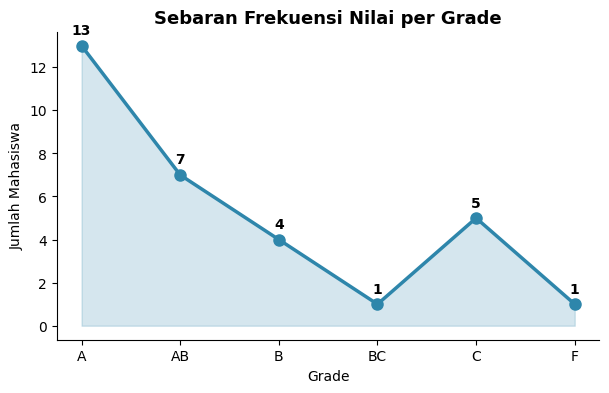

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4))
x = datafrq.index
y = datafrq['Frekuensi']

ax.plot(x, y, marker='o', markersize=8, color='#2E86AB', linewidth=2.5)
ax.fill_between(x, y, color='#2E86AB', alpha=0.2)

for xi, yi in zip(x, y):
    ax.annotate(str(yi), (xi, yi), textcoords="offset points", xytext=(0,8), ha='center', fontweight='bold')

ax.set_title("Sebaran Frekuensi Nilai per Grade", fontsize=13, fontweight='bold')
ax.set_ylabel("Jumlah Mahasiswa")
ax.set_xlabel("Grade")
ax.spines[['top','right']].set_visible(False)
plt.show()

>## Grafik Batang

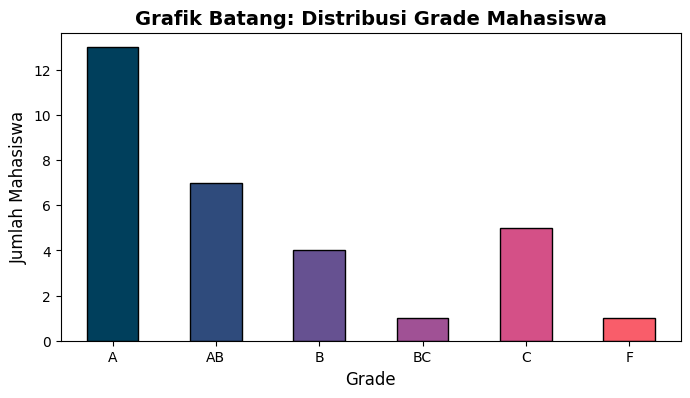

In [18]:
plt.figure(figsize=(8, 4))

warna_bar_biru = ['#003f5c', '#2f4b7c', '#665191', '#a05195', '#d45087', '#f95d6a']
datafrq['Frekuensi'].plot(kind='bar', color=warna_bar_biru, edgecolor='black')
plt.title('Grafik Batang: Distribusi Grade Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Grade', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks(rotation=0)
plt.show()

>## Pie Chart

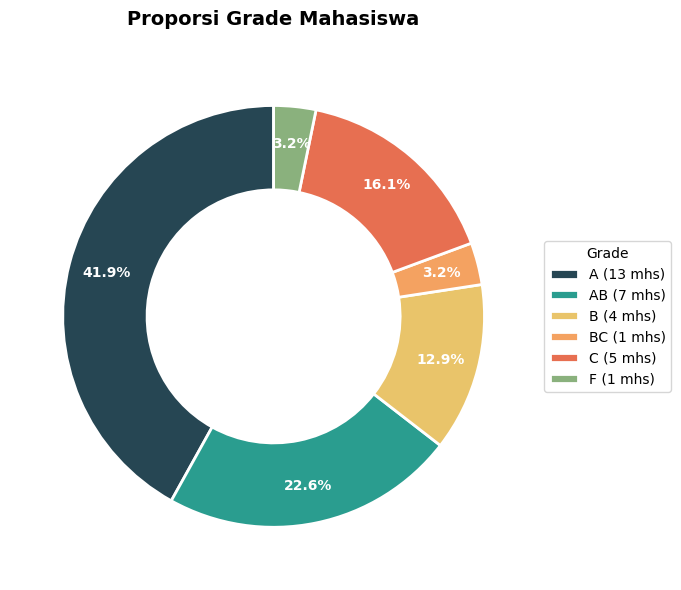

In [13]:
plt.style.use('default')

fig, ax = plt.subplots(figsize=(8,6))
freq = datafrq['Frekuensi']
colors = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51','#8AB17D']

wedges, texts, autotexts = ax.pie(
    freq, autopct='%1.1f%%', startangle=90,
    colors=colors[:len(freq)], pctdistance=0.82,
    wedgeprops={'width':0.4, 'edgecolor':'white', 'linewidth':2}
)

for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(10)

ax.legend(wedges, [f"{g} ({v} mhs)" for g, v in zip(freq.index, freq)],
          title="Grade", loc="center left", bbox_to_anchor=(1, 0.1, 0.4, 0.8))

ax.set_title("Proporsi Grade Mahasiswa", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# C. Statistika Deskriptif

In [14]:
dataraw["Final Score"] = pd.to_numeric(dataraw["Final Score"], errors='coerce')
dt = dataraw["Final Score"]

stats = dt.describe()
stats['Standard Error'] = dt.sem()
stats['Median'] = dt.median()
stats['Mode'] = dt.mode().iloc[0]
stats['Variance'] = dt.var()
stats['Range'] = dt.max() - dt.min()
stats['Skewness'] = dt.skew()
stats['Kurtosis'] = dt.kurtosis()

stats_df = stats.round(5).to_frame(name="Nilai")

stats_df = stats_df.reset_index().rename(columns={'index': 'Statistik'})

tabel_rapi = stats_df.style.set_caption("Tabel Statistika Deskriptif - Final Score") \
                           .hide(axis="index") \
                           .format({"Nilai": "{:.5f}"})

display(tabel_rapi)

Statistik,Nilai
count,31.00000
mean,76.49968
std,13.33063
min,46.01000
25%,68.80000
50%,79.30000
75%,86.79000
max,94.03000
Standard Error,2.39425
Median,79.30000
